# Dataset Description
## Imports, US vs. China first 6 months each year

**Source**: DANE

**Download**: [Link](https://www.dane.gov.co/index.php/estadisticas-por-tema/comercio-internacional/importaciones)

# Code
## Imports

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: "%.2f" % x)

## Load data

In [39]:
path = "./data/importaciones_paises_origen.csv"

df = pd.read_csv(path, encoding="utf-8")

## Clean data

In [40]:
df["Fecha"] = pd.to_datetime(df["Fecha"])

df_f = df[
    (df["País"].str.lower().isin(["estados unidos", "china"])) &
    (df["Fecha"].dt.month < 7)
]

df_f["Fecha"] = df_f["Fecha"].dt.year
by_year = df_f.groupby(["Fecha", "País"]).sum().reset_index()

china = (by_year
         [by_year["País"].str.lower().eq("china")]
         .set_index("Fecha")
         ["Miles_USD_CIF"]
)

us = (by_year
         [by_year["País"].str.lower().eq("estados unidos")]
         .set_index("Fecha")
         ["Miles_USD_CIF"]
)

## Plot

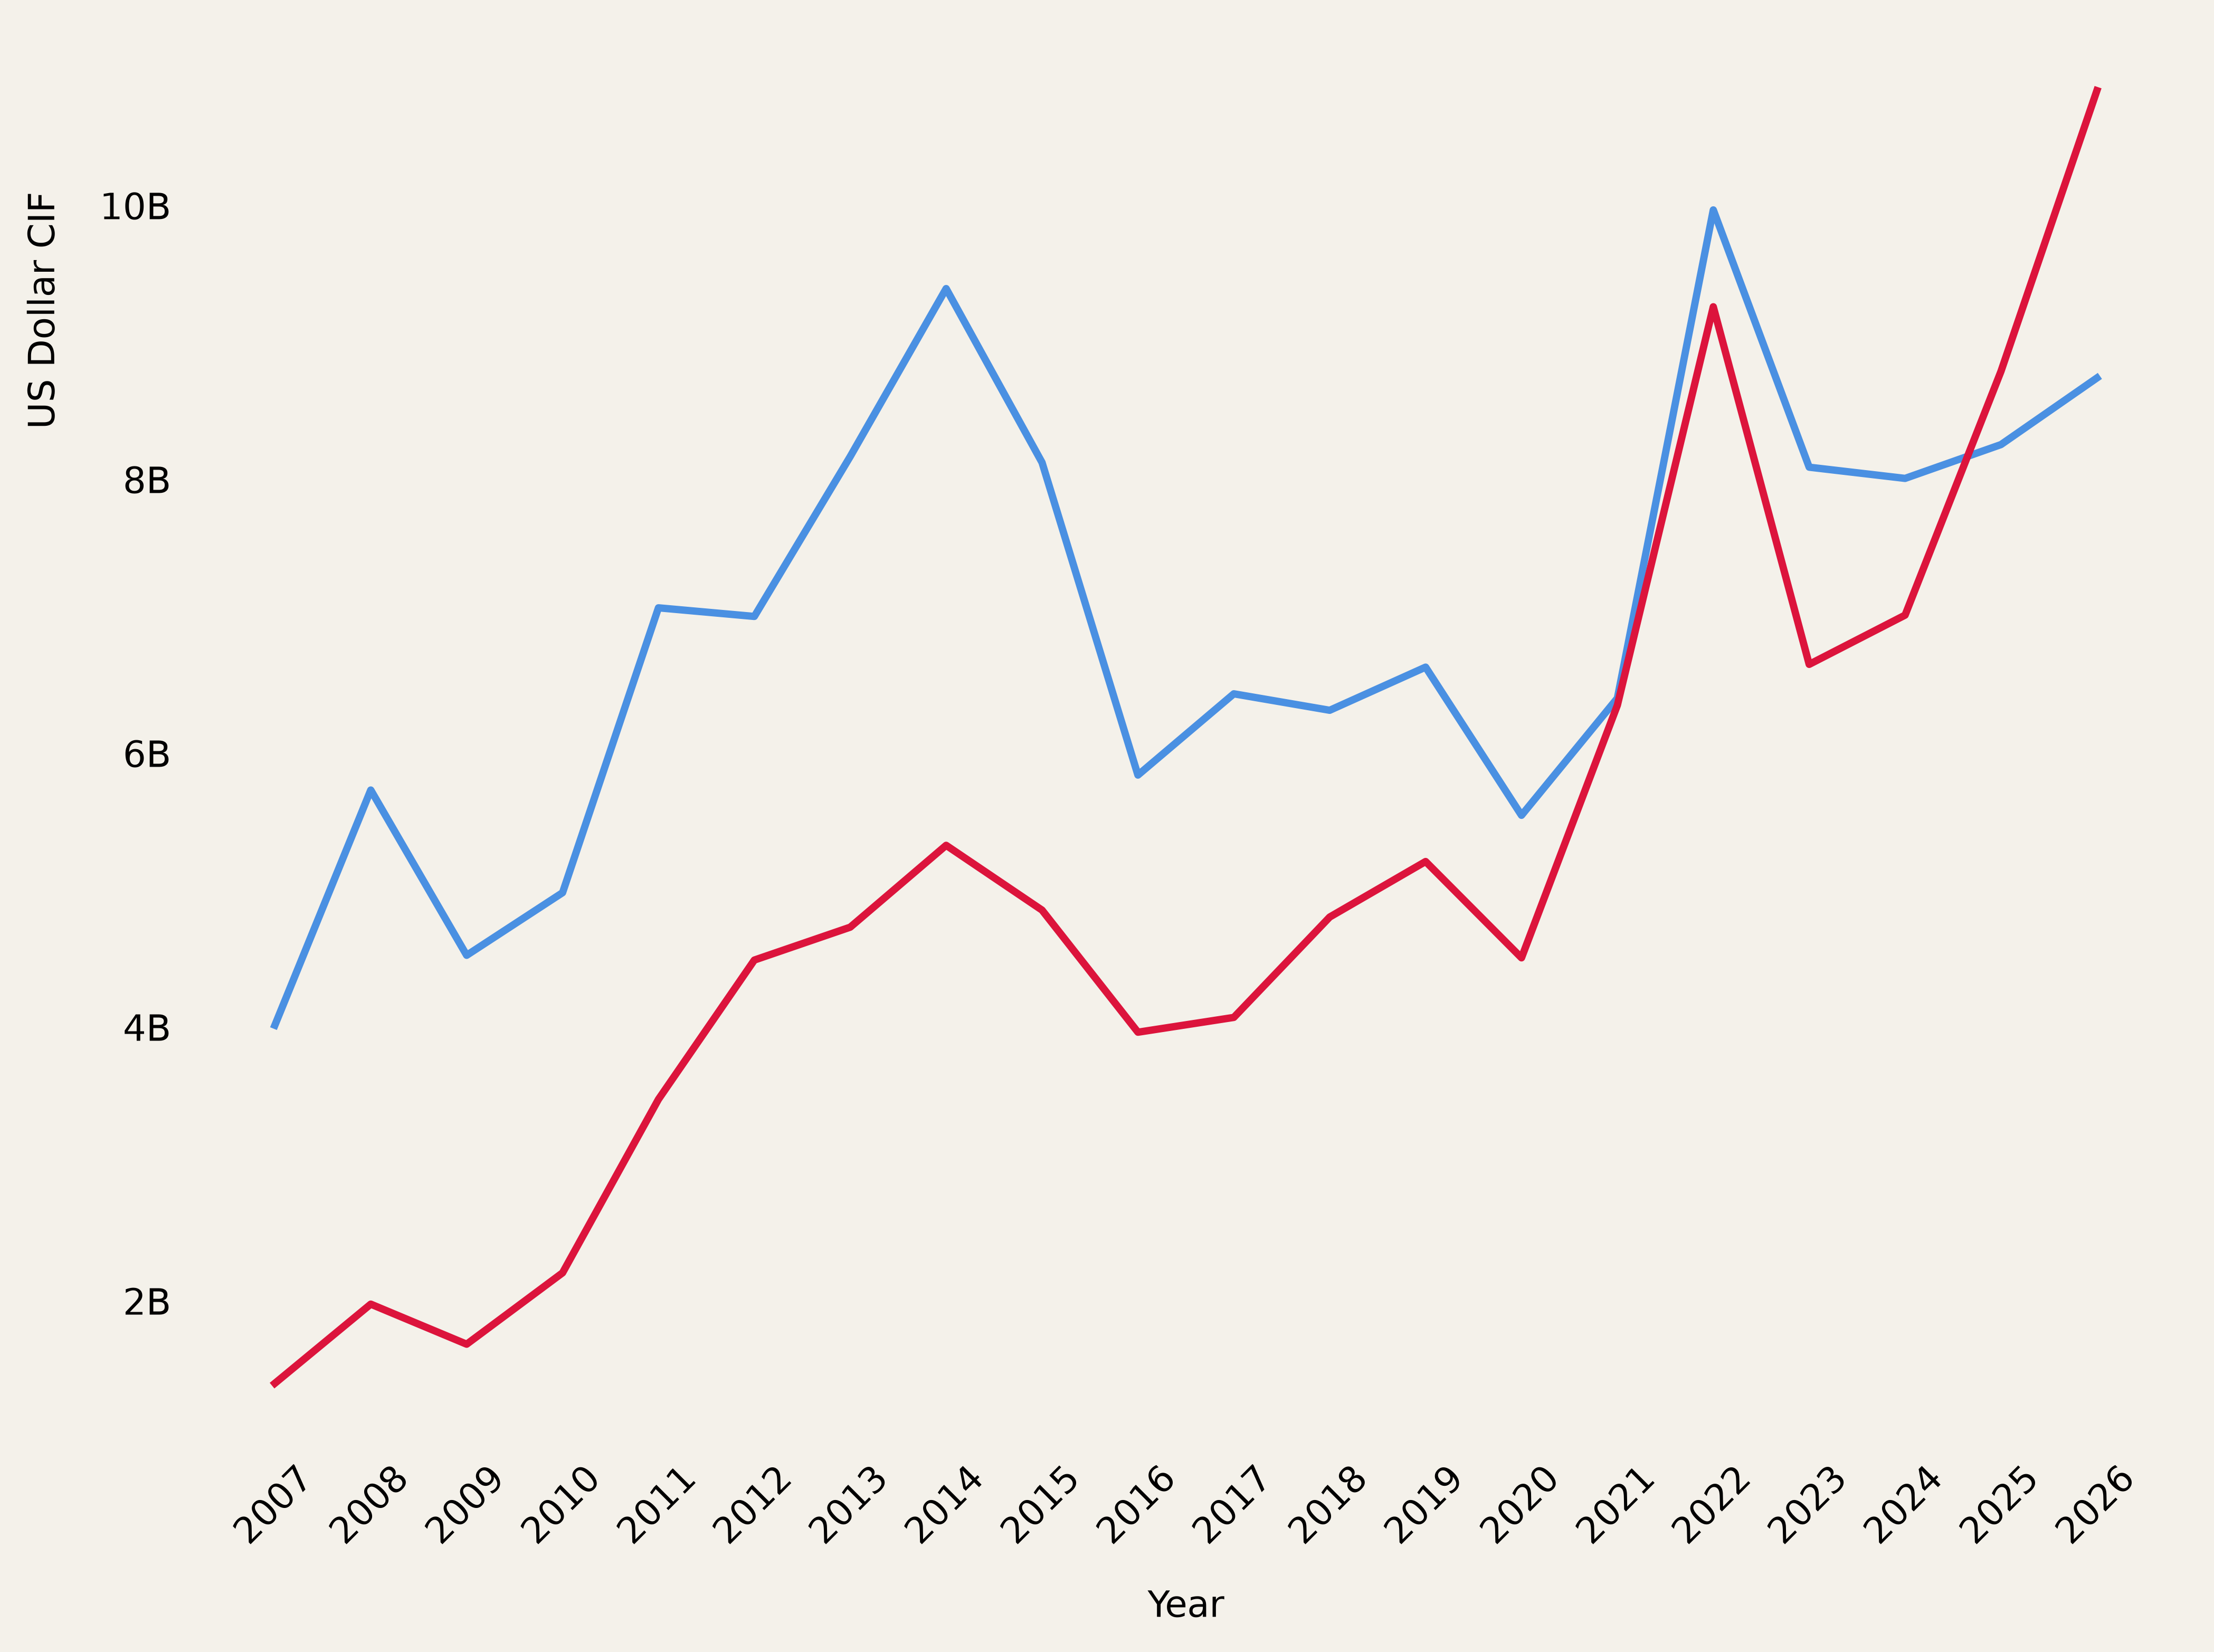

In [41]:
background = "#F4F1EA"
blue = "#4a90e2"
red = "#DC143C"

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.plot(us, linewidth=2, color=blue)
plt.plot(china, linewidth=2, color=red)

plt.xticks(us.index, rotation=45)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000000)}B"))

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("US Dollar CIF", labelpad=10, fontsize=10, y=0.8)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.show()